# v14 — Monte Carlo Simulation: seberapa dalam drawdown bisa terjadi dalam skenario yang REALISTIS?

**Masalah yang diselesaikan:** backtest v13 kasih satu angka `max_drawdown_pct = -34.18%` (TEST,
196 trade). Tapi angka itu berasal dari SATU urutan trade spesifik yang kebetulan terjadi di
2026-03 s/d 2026-08. Kumpulan trade yang PERSIS SAMA (menang/kalah & besaran PnL-nya), kalau
urutannya beda -- misal semua LOSS kebetulan mengumpul di awal, bukan tersebar -- bisa
menghasilkan max drawdown yang jauh lebih dalam dari -34.18%, meski win rate & profit factor
keseluruhan TIDAK BERUBAH SAMA SEKALI (itu cuma soal urutan, bukan soal kualitas sinyal).

**Metodologi:**
1. Ambil daftar PnL tiap trade dari backtest TEST v13 (196 trade, out-of-sample, params FIXED
   dari TRAIN -- ini yang paling representatif utk kondisi live, bukan full period yg termasuk
   data yg dipakai nyari parameter)
2. Acak urutan 196 PnL ini 10.000 kali (bootstrap tanpa penggantian -- reshuffle, BUKAN resample
   dgn penggantian, supaya distribusi menang/kalah/besaran tetap identik, cuma urutannya beda)
3. Tiap kali diacak, hitung ulang equity curve & max drawdown dari urutan baru itu
4. Lihat distribusinya: median, persentil 75/90/95/99 -- ini kasih "worst case realistis"
   utk sizing modal/risk, bukan cuma satu skenario yang kebetulan terjadi
5. Ulangi juga dgn dataset full period (721 trade, 2025-2026, termasuk TRAIN) sbg pembanding
   sample size lebih besar -- meski sedikit bias optimis krn termasuk data yg dipakai tuning

**Bukan riset ubah parameter/strategi** -- v14 TIDAK mengubah sinyal, TP/SL, atau filter apa pun
dari v13. Ini murni **analisis risiko** dari hasil v13 yang sudah ada, buat jawab pertanyaan
"kalau saya nggak siap kehilangan X%, apakah sizing saya (lot 0.01 fixed) kegedean?" Cocok jadi
langkah pertama dari 3 isu "pematangan v13" yang direncanakan (Monte Carlo, lalu 2 isu lain
menyusul terpisah).

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

STRATEGY_NAME = "m5_scalping"
VERSION = "v14"

PROCESSED_DIR = PROJECT_ROOT / "dataset" / "processed" / STRATEGY_NAME
EXPORT_DIR = PROJECT_ROOT / "dataset" / "exports" / STRATEGY_NAME / VERSION
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

INITIAL_EQUITY = 100.0
N_SIMULATIONS = 10_000
RNG_SEED = 42  # fixed seed -- hasil reproducible, bukan berubah tiap kali notebook dijalankan ulang

pd.set_option("display.width", 160)
plt.rcParams["figure.figsize"] = (14, 5)
rng = np.random.default_rng(RNG_SEED)

## 1. Load trade log v13 (PnL per trade, dua dataset)

- **TEST** (`trade_log_test_small_profit.csv`, 196 trade, 2026-03 s/d 2026-08): out-of-sample murni,
  parameter TIDAK di-tuning di rentang ini -- paling representatif utk kondisi live. **Analisis utama.**
- **Full period** (`trade_log_full_final.csv`, 721 trade, 2025-01 s/d 2026-08): termasuk TRAIN (data
  yg dipakai cari parameter) -- sample size lebih besar (Monte Carlo lebih stabil), tapi sedikit bias
  optimis. **Pembanding sekunder.**

In [2]:
df_test = pd.read_csv(PROCESSED_DIR / "v13" / "trade_log_test_small_profit.csv")
df_test["entry_time"] = pd.to_datetime(df_test["entry_time"])
df_test = df_test.sort_values("entry_time").reset_index(drop=True)

df_full = pd.read_csv(PROCESSED_DIR / "v13" / "trade_log_full_final.csv")
df_full["entry_time"] = pd.to_datetime(df_full["entry_time"])
df_full = df_full.sort_values("entry_time").reset_index(drop=True)

print(f"TEST (out-of-sample): {len(df_test)} trade, {df_test['entry_time'].min()} -> {df_test['entry_time'].max()}")
print(f"  win_rate={100*(df_test['pnl']>0).mean():.2f}%  net_pnl=${df_test['pnl'].sum():.2f}")
print(f"\nFull period: {len(df_full)} trade, {df_full['entry_time'].min()} -> {df_full['entry_time'].max()}")
print(f"  win_rate={100*(df_full['pnl']>0).mean():.2f}%  net_pnl=${df_full['pnl'].sum():.2f}")

TEST (out-of-sample): 196 trade, 2026-03-02 20:30:00+00:00 -> 2026-08-05 23:40:00+00:00
  win_rate=75.00%  net_pnl=$1178.82

Full period: 721 trade, 2025-01-06 00:55:00+00:00 -> 2026-08-05 23:40:00+00:00
  win_rate=70.60%  net_pnl=$5145.27


## 1b. Bangun trade log FULL 2019-2026 dengan lot FIXED (khusus Monte Carlo)

`trade_log_full_2019_2026.csv` yang sudah ada (dari stress test v13) pakai **compounding**
position sizing (`RISK_PCT=0.01` dari equity yang terus tumbuh) -- PnL per trade meledak dari
rata-rata $0.32 (2019) ke $7756 (2026) krn lot ikut membesar seiring waktu. Kalau dipakai
langsung utk Monte Carlo, hasil reshuffle akan didominasi trade-trade akhir yang lot-nya sudah
raksasa, bukan mencerminkan risiko urutan yang adil di seluruh periode.

**Solusi:** re-run backtest final (v12+OB filter+exhaustion) di seluruh 2019-2026 dgn **lot
FIXED** (`FIXED_LOT = 0.01`, sama seperti live saat ini di `.env` `XAUUSD_LOT_SIZE`) -- bukan
`calc_lot()` berbasis equity. Ini bikin PnL antar-trade sepanjang 7.6 tahun sebanding, sehingga
reshuffle Monte Carlo mengukur risiko urutan yang sesungguhnya, bukan artefak compounding.
Sinyal (kapan entry, arah, SL/TP dalam satuan ATR) TETAP SAMA PERSIS dgn v13 -- cuma lot-nya
yang dibuat konstan.

In [3]:
FIXED_LOT = 0.01  # sama dgn XAUUSD_LOT_SIZE default di .env -- konstan, TIDAK berbasis equity
CONTRACT_SIZE_1926 = 100.0
SPREAD_POINTS_1926 = 0.30
SL_MULT_1926, TP_MULT_1926 = 2.0, 4.0
MAX_HOLD_1926 = 12
SL_SMALL_1926, TP_SMALL_1926 = 1.25, 1.0
MAX_HOLD_SMALL_1926 = 6
ADX_MIN_1926 = 18.0
ATR_MIN_PCT_1926 = 0.03
MIN_SIGNAL_SCORE_1926 = 9.0

OSCILLATOR_CLUSTER_1926 = ["rsi", "stoch", "williams_r", "cci", "bb", "vwap"]
TREND_CLUSTER_1926 = ["sma", "ichimoku", "supertrend"]
OLD_WEIGHTS_1926 = {
    "rsi": 1.0, "stoch": 1.0, "williams_r": 1.0, "cci": 1.0, "bb": 1.0, "vwap": 1.5,
    "sma": 1.5, "ichimoku": 2.5, "supertrend": 2.5,
}
OSCILLATOR_WEIGHT_1926 = round(np.mean([1.0, 1.0, 1.0, 1.0, 1.0, 1.5]), 2)
TREND_WEIGHT_1926 = round(np.mean([1.5, 2.5, 2.5]), 2)


def check_h1_alignment_1926(row, direction):
    h1_ema_50 = row.get("h1_ema_50")
    h1_ema_200 = row.get("h1_ema_200")
    if h1_ema_50 is None or h1_ema_200 is None or pd.isna(h1_ema_50) or pd.isna(h1_ema_200):
        return True
    h1_trend = "UP" if h1_ema_50 > h1_ema_200 else ("DOWN" if h1_ema_50 < h1_ema_200 else "FLAT")
    if direction == "BUY" and h1_trend == "DOWN":
        return False
    if direction == "SELL" and h1_trend == "UP":
        return False
    return True


def has_opposing_ob_1926(row, direction):
    if direction == "BUY":
        return bool(row["ob_bear"] > 0 or row["h1_ob_bear"] > 0)
    return bool(row["ob_bull"] > 0 or row["h1_ob_bull"] > 0)


def build_direction_column_1926(df_signals):
    score = df_signals["v12_raw_score"]
    direction = pd.Series("WAIT", index=df_signals.index)
    direction[score >= MIN_SIGNAL_SCORE_1926] = "BUY"
    direction[score <= -MIN_SIGNAL_SCORE_1926] = "SELL"
    for idx in direction[direction != "WAIT"].index:
        row = df_signals.loc[idx]
        d = direction.loc[idx]
        if not check_h1_alignment_1926(row, d) or has_opposing_ob_1926(row, d):
            direction.loc[idx] = "WAIT"
    return direction


def run_backtest_fixed_lot_1926(df_signals: pd.DataFrame) -> pd.DataFrame:
    """Backtest final v13 (v12 scoring + OB filter + exhaustion), tapi lot FIXED (bukan
    calc_lot berbasis equity) -- khusus supaya PnL antar-trade sebanding utk Monte Carlo."""
    df_signals = df_signals.copy()
    df_signals["signal_direction"] = build_direction_column_1926(df_signals)

    trades = []
    i = 0
    n = len(df_signals)

    while i < n:
        row = df_signals.iloc[i]
        direction = row["signal_direction"]
        if direction == "WAIT":
            i += 1
            continue

        dominant_chain = row["bull_chain"] if direction == "BUY" else row["bear_chain"]
        chain_maxed = dominant_chain >= 8
        cur_sl_mult, cur_tp_mult, cur_max_hold = SL_MULT_1926, TP_MULT_1926, MAX_HOLD_1926
        if chain_maxed:
            cur_sl_mult, cur_tp_mult, cur_max_hold = SL_SMALL_1926, TP_SMALL_1926, MAX_HOLD_SMALL_1926

        atr = row["atr"]
        if not np.isfinite(atr) or atr <= 0:
            i += 1
            continue

        sl_points = cur_sl_mult * atr
        tp_points = cur_tp_mult * atr
        entry_price = row["close"] + (SPREAD_POINTS_1926 if direction == "BUY" else -SPREAD_POINTS_1926)
        entry_time = row["datetime"]

        if direction == "BUY":
            tp_price, sl_price = entry_price + tp_points, entry_price - sl_points
        else:
            tp_price, sl_price = entry_price - tp_points, entry_price + sl_points

        exit_price = None
        exit_idx = min(i + cur_max_hold, n - 1)
        window_end = min(i + 1 + cur_max_hold, n)
        for candle_idx in range(i + 1, window_end):
            candle = df_signals.iloc[candle_idx]
            hit_tp = candle["high"] >= tp_price if direction == "BUY" else candle["low"] <= tp_price
            hit_sl = candle["low"] <= sl_price if direction == "BUY" else candle["high"] >= sl_price
            if hit_sl:
                exit_price, exit_time = sl_price, candle["datetime"]
                exit_idx = candle_idx
                break
            if hit_tp:
                exit_price, exit_time = tp_price, candle["datetime"]
                exit_idx = candle_idx
                break
        if exit_price is None:
            last_candle = df_signals.iloc[exit_idx]
            exit_price, exit_time = last_candle["close"], last_candle["datetime"]

        next_i = exit_idx + 1
        price_move = (exit_price - entry_price) if direction == "BUY" else (entry_price - exit_price)
        pnl = price_move * FIXED_LOT * CONTRACT_SIZE_1926
        trades.append({
            "entry_time": entry_time, "direction": direction, "pnl": pnl,
            "result": "WIN" if pnl > 0 else "LOSS",
        })
        i = next_i

    return pd.DataFrame(trades)


def score_de_redundant_1926(row: pd.Series) -> float:
    close = float(row["close"])
    atr = float(row.get("atr", close * 0.001))
    raw_scores = {
        "rsi": score_rsi(row)[0] / OLD_WEIGHTS_1926["rsi"],
        "stoch": score_stoch(row)[0] / OLD_WEIGHTS_1926["stoch"],
        "williams_r": score_williams_r(row)[0] / OLD_WEIGHTS_1926["williams_r"],
        "cci": score_cci(row)[0] / OLD_WEIGHTS_1926["cci"],
        "bb": score_bb(row, close)[0] / OLD_WEIGHTS_1926["bb"],
        "vwap": score_vwap(row, close)[0] / OLD_WEIGHTS_1926["vwap"],
        "sma": score_sma(row, close)[0] / OLD_WEIGHTS_1926["sma"],
        "ichimoku": score_ichimoku(row, close)[0] / OLD_WEIGHTS_1926["ichimoku"],
        "supertrend": score_supertrend(row)[0] / OLD_WEIGHTS_1926["supertrend"],
    }
    oscillator_raw = np.median([raw_scores[c] for c in OSCILLATOR_CLUSTER_1926])
    trend_raw = np.median([raw_scores[c] for c in TREND_CLUSTER_1926])
    components = {
        "oscillator_composite": oscillator_raw * OSCILLATOR_WEIGHT_1926,
        "trend_composite": trend_raw * TREND_WEIGHT_1926,
        "macd": score_macd(row)[0],
        "adx": score_adx(row)[0],
        "candle": score_candle(row)[0],
        "extra_patterns": score_extra_patterns(row)[0],
        "obv": score_obv(row)[0],
        "mfi": score_mfi(row)[0],
        "fibonacci": score_fibonacci(row, close, atr)[0],
        "rsi_divergence": score_rsi_divergence(row)[0],
        "momentum_chain": score_momentum_chain(row)[0],
        "psar": score_psar(row)[0],
        "smc": score_smc(row)[0],
    }
    return round(sum(components.values()), 3)

In [4]:
FULL_2019_2026_TRADE_LOG_FIXED_LOT_PATH = PROCESSED_DIR / "v14" / "trade_log_full_2019_2026_fixed_lot.csv"
(PROCESSED_DIR / "v14").mkdir(parents=True, exist_ok=True)

if FULL_2019_2026_TRADE_LOG_FIXED_LOT_PATH.exists():
    print(f"Sudah ada, load dari cache: {FULL_2019_2026_TRADE_LOG_FIXED_LOT_PATH}")
    df_full_1926 = pd.read_csv(FULL_2019_2026_TRADE_LOG_FIXED_LOT_PATH)
    df_full_1926["entry_time"] = pd.to_datetime(df_full_1926["entry_time"])
else:
    print("Belum ada cache -- generate dari awal (proses berat, ~518K candle, bisa 15-25 menit)...")
    import time as _time

    from app.utils.signals.scoring import (
        score_adx, score_bb, score_candle, score_cci, score_extra_patterns,
        score_fibonacci, score_ichimoku, score_macd, score_mfi, score_momentum_chain,
        score_obv, score_psar, score_rsi, score_rsi_divergence, score_sma, score_smc,
        score_stoch, score_supertrend, score_vwap, score_williams_r,
    )

    df_m5_full = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_m5_full_indicators.csv")
    df_m5_full["datetime"] = pd.to_datetime(df_m5_full["datetime"])
    df_m5_full = df_m5_full.sort_values("datetime").reset_index(drop=True)

    df_h1_full = pd.read_csv(PROCESSED_DIR / "v01" / "xauusd_h1_full_indicators.csv")
    df_h1_full["datetime"] = pd.to_datetime(df_h1_full["datetime"])
    df_h1_full = df_h1_full.sort_values("datetime").reset_index(drop=True)

    df_h1_full_shifted = df_h1_full.copy()
    df_h1_full_shifted["h1_available_at"] = df_h1_full_shifted["datetime"] + pd.Timedelta(hours=1)
    h1_cols = [c for c in df_h1_full_shifted.columns if c != "h1_available_at"]
    df_h1_full_shifted = df_h1_full_shifted[["h1_available_at", *h1_cols]].rename(columns={c: f"h1_{c}" for c in h1_cols})

    df_1926 = pd.merge_asof(
        df_m5_full.sort_values("datetime"), df_h1_full_shifted.sort_values("h1_available_at"),
        left_on="datetime", right_on="h1_available_at", direction="backward",
    )
    print(f"FULL 2019-2026 dataset: {len(df_1926)} baris, {df_1926['datetime'].min()} -> {df_1926['datetime'].max()}")

    t0 = _time.time()
    scores = np.full(len(df_1926), np.nan)
    close_arr = df_1926["close"].to_numpy()
    adx_arr = df_1926["adx"].to_numpy()
    atr_arr = df_1926["atr"].to_numpy()

    for pos in range(len(df_1926)):
        if adx_arr[pos] < ADX_MIN_1926 or (close_arr[pos] > 0 and (atr_arr[pos] / close_arr[pos] * 100) < ATR_MIN_PCT_1926):
            continue
        row = df_1926.iloc[pos]
        scores[pos] = score_de_redundant_1926(row)
        if pos % 100_000 == 0:
            print(f"  scoring progress: {pos}/{len(df_1926)} ({_time.time()-t0:.0f}s elapsed)")

    df_1926["v12_raw_score"] = scores
    print(f"Scoring done in {_time.time()-t0:.0f}s. Non-null: {df_1926['v12_raw_score'].notna().sum()}")

    df_full_1926 = run_backtest_fixed_lot_1926(df_1926)
    df_full_1926.to_csv(FULL_2019_2026_TRADE_LOG_FIXED_LOT_PATH, index=False)
    print(f"Tersimpan ke cache: {FULL_2019_2026_TRADE_LOG_FIXED_LOT_PATH}")

print(f"\nFull 2019-2026 (lot fixed): {len(df_full_1926)} trade, "
      f"{df_full_1926['entry_time'].min()} -> {df_full_1926['entry_time'].max()}")
print(f"  win_rate={100*(df_full_1926['pnl']>0).mean():.2f}%  net_pnl=${df_full_1926['pnl'].sum():.2f}")

Sudah ada, load dari cache: D:\Projects\robot-scalping\dataset\processed\m5_scalping\v14\trade_log_full_2019_2026_fixed_lot.csv

Full 2019-2026 (lot fixed): 3056 trade, 2019-01-02 04:45:00+00:00 -> 2026-08-05 23:40:00+00:00
  win_rate=62.14%  net_pnl=$4914.50


## 2. Engine Monte Carlo

**Reshuffle (permutation), bukan resample dgn penggantian (bootstrap klasik):** tiap simulasi
memakai PERSIS 196 (atau 721) PnL yang sama, cuma diacak urutannya. Ini sengaja dipilih drpd
resample-with-replacement supaya distribusi menang/kalah & besaran PnL keseluruhan TIDAK BERUBAH
sama sekali antar simulasi -- yang diuji murni "apakah urutan kejadian yang kebetulan terjadi di
backtest itu urutan yang beruntung atau apes", bukan "seberapa reliable statistik win rate-nya"
(itu pertanyaan berbeda, butuh bootstrap dgn penggantian, di luar cakupan v14 ini).

Equity dihitung SEDERHANA (equity += pnl, bukan re-compounding lot size spt engine backtest asli)
krn PnL tiap trade di CSV sudah hasil lot yg dihitung dari equity SAAT backtest asli jalan -- reshuffle
urutan otomatis mengubah "equity saat itu" jadi tidak match lagi dgn lot yg sudah dipakai. Ini
simplifikasi yg disengaja: max_drawdown_pct dihitung relatif ke `INITIAL_EQUITY + running peak`,
sama presisinya dgn cara `evaluate()` di notebook-notebook sebelumnya (v09, v13), cukup akurat utk
tujuan analisis risiko urutan (bukan re-simulasi position sizing dari nol).

In [5]:
def max_drawdown_pct_from_curve(equity_curve: np.ndarray) -> float:
    running_max = np.maximum.accumulate(equity_curve)
    drawdown = (equity_curve - running_max) / running_max * 100
    return float(drawdown.min())


def run_monte_carlo(pnl_array: np.ndarray, initial_equity: float, n_sims: int, rng: np.random.Generator) -> pd.DataFrame:
    """Reshuffle urutan pnl_array n_sims kali, hitung max_drawdown_pct & final_equity tiap kali."""
    results = np.empty((n_sims, 2))  # kolom: [max_drawdown_pct, final_equity]

    for sim in range(n_sims):
        shuffled = rng.permutation(pnl_array)
        equity_curve = initial_equity + np.concatenate([[0.0], np.cumsum(shuffled)])
        results[sim, 0] = max_drawdown_pct_from_curve(equity_curve)
        results[sim, 1] = equity_curve[-1]

    return pd.DataFrame(results, columns=["max_drawdown_pct", "final_equity"])


def summarize_mc(mc_df: pd.DataFrame, actual_dd_pct: float, actual_final_equity: float, label: str) -> dict:
    dd = mc_df["max_drawdown_pct"]  # negatif, makin kecil (makin negatif) = makin dalam
    return {
        "label": label,
        "n_simulations": len(mc_df),
        "actual_backtest_dd_pct": round(actual_dd_pct, 2),
        "actual_backtest_final_equity": round(actual_final_equity, 2),
        "mc_median_dd_pct": round(dd.median(), 2),
        "mc_p75_dd_pct": round(dd.quantile(0.25), 2),  # persentil 75 "terburuk" = quantile 0.25 dari nilai negatif
        "mc_p90_dd_pct": round(dd.quantile(0.10), 2),
        "mc_p95_dd_pct": round(dd.quantile(0.05), 2),
        "mc_p99_dd_pct": round(dd.quantile(0.01), 2),
        "mc_worst_dd_pct": round(dd.min(), 2),
        "mc_best_dd_pct": round(dd.max(), 2),
        "pct_sims_worse_than_actual": round((dd < actual_dd_pct).mean() * 100, 1),
    }

## 3. Jalankan Monte Carlo — TEST set (196 trade, out-of-sample) — ANALISIS UTAMA

In [6]:
pnl_test = df_test["pnl"].to_numpy()

# Actual backtest (urutan asli, kronologis) sbg baseline pembanding
actual_curve_test = INITIAL_EQUITY + np.concatenate([[0.0], np.cumsum(pnl_test)])
actual_dd_test = max_drawdown_pct_from_curve(actual_curve_test)
actual_final_test = actual_curve_test[-1]
print(f"Actual backtest TEST: max_drawdown={actual_dd_test:.2f}%  final_equity=${actual_final_test:.2f}")
print("(cocok dgn models/m5_scalping/v13/params.json -> test_period_only.max_drawdown_pct = -34.18)")

mc_test = run_monte_carlo(pnl_test, INITIAL_EQUITY, N_SIMULATIONS, rng)
summary_test = summarize_mc(mc_test, actual_dd_test, actual_final_test, "TEST (196 trade, out-of-sample)")

print(f"\n=== Monte Carlo TEST set ({N_SIMULATIONS:,} reshuffle) ===")
for k, v in summary_test.items():
    print(f"  {k}: {v}")

Actual backtest TEST: max_drawdown=-34.18%  final_equity=$1278.82
(cocok dgn models/m5_scalping/v13/params.json -> test_period_only.max_drawdown_pct = -34.18)

=== Monte Carlo TEST set (10,000 reshuffle) ===
  label: TEST (196 trade, out-of-sample)
  n_simulations: 10000
  actual_backtest_dd_pct: -34.18
  actual_backtest_final_equity: 1278.82
  mc_median_dd_pct: -16.47
  mc_p75_dd_pct: -24.28
  mc_p90_dd_pct: -34.21
  mc_p95_dd_pct: -40.81
  mc_p99_dd_pct: -58.56
  mc_worst_dd_pct: -99.5
  mc_best_dd_pct: -4.12
  pct_sims_worse_than_actual: 10.0


## 4. Jalankan Monte Carlo — Full period (721 trade, 2025-2026) — PEMBANDING SEKUNDER

In [7]:
pnl_full = df_full["pnl"].to_numpy()

actual_curve_full = INITIAL_EQUITY + np.concatenate([[0.0], np.cumsum(pnl_full)])
actual_dd_full = max_drawdown_pct_from_curve(actual_curve_full)
actual_final_full = actual_curve_full[-1]
print(f"Actual backtest full period: max_drawdown={actual_dd_full:.2f}%  final_equity=${actual_final_full:.2f}")

mc_full = run_monte_carlo(pnl_full, INITIAL_EQUITY, N_SIMULATIONS, rng)
summary_full = summarize_mc(mc_full, actual_dd_full, actual_final_full, "Full period (721 trade, termasuk TRAIN)")

print(f"\n=== Monte Carlo full period ({N_SIMULATIONS:,} reshuffle) ===")
for k, v in summary_full.items():
    print(f"  {k}: {v}")

Actual backtest full period: max_drawdown=-5.69%  final_equity=$5245.27



=== Monte Carlo full period (10,000 reshuffle) ===
  label: Full period (721 trade, termasuk TRAIN)
  n_simulations: 10000
  actual_backtest_dd_pct: -5.69
  actual_backtest_final_equity: 5245.27
  mc_median_dd_pct: -18.58
  mc_p75_dd_pct: -28.98
  mc_p90_dd_pct: -42.62
  mc_p95_dd_pct: -52.84
  mc_p99_dd_pct: -79.5
  mc_worst_dd_pct: -171.96
  mc_best_dd_pct: -3.38
  pct_sims_worse_than_actual: 98.9


## 4b. Jalankan Monte Carlo — Full 2019-2026 lot FIXED (3056 trade, 7.6 tahun) — SAMPLE TERBESAR

Sample jauh lebih besar (3056 vs 196/721 trade) & mencakup seluruh rezim harga XAUUSD
($1300-$4500+) yang divalidasi robust di v13 stress test -- Monte Carlo di sini paling stabil
scr statistik, meski PnL per trade (lot fixed 0.01) beda skala absolut dari live saat ini
(tergantung equity riil akun).

In [8]:
pnl_1926 = df_full_1926["pnl"].to_numpy()

actual_curve_1926 = INITIAL_EQUITY + np.concatenate([[0.0], np.cumsum(pnl_1926)])
actual_dd_1926 = max_drawdown_pct_from_curve(actual_curve_1926)
actual_final_1926 = actual_curve_1926[-1]
print(f"Actual backtest full 2019-2026 (lot fixed): max_drawdown={actual_dd_1926:.2f}%  final_equity=${actual_final_1926:.2f}")

mc_1926 = run_monte_carlo(pnl_1926, INITIAL_EQUITY, N_SIMULATIONS, rng)
summary_1926 = summarize_mc(mc_1926, actual_dd_1926, actual_final_1926, "Full 2019-2026 lot fixed (3056 trade, 7.6 tahun)")

print(f"\n=== Monte Carlo full 2019-2026 lot fixed ({N_SIMULATIONS:,} reshuffle) ===")
for k, v in summary_1926.items():
    print(f"  {k}: {v}")

Actual backtest full 2019-2026 (lot fixed): max_drawdown=-11.72%  final_equity=$5014.50



=== Monte Carlo full 2019-2026 lot fixed (10,000 reshuffle) ===
  label: Full 2019-2026 lot fixed (3056 trade, 7.6 tahun)
  n_simulations: 10000
  actual_backtest_dd_pct: -11.72
  actual_backtest_final_equity: 5014.5
  mc_median_dd_pct: -12.75
  mc_p75_dd_pct: -18.18
  mc_p90_dd_pct: -25.5
  mc_p95_dd_pct: -32.31
  mc_p99_dd_pct: -50.91
  mc_worst_dd_pct: -100.01
  mc_best_dd_pct: -3.14
  pct_sims_worse_than_actual: 56.9


## 5. Tabel ringkasan & interpretasi

In [9]:
summary_table = pd.DataFrame([summary_test, summary_full, summary_1926]).set_index("label")
summary_table

,n_simulations,actual_backtest_dd_pct,actual_backtest_final_equity,mc_median_dd_pct,mc_p75_dd_pct,mc_p90_dd_pct,mc_p95_dd_pct,mc_p99_dd_pct,mc_worst_dd_pct,mc_best_dd_pct,pct_sims_worse_than_actual
label,,,,,,,,,,,
"TEST (196 trade, out-of-sample)",10000,-34.18,1278.82,-16.47,-24.28,-34.21,-40.81,-58.56,-99.50,-4.12,10.0
"Full period (721 trade, termasuk TRAIN)",10000,-5.69,5245.27,-18.58,-28.98,-42.62,-52.84,-79.50,-171.96,-3.38,98.9
"Full 2019-2026 lot fixed (3056 trade, 7.6 tahun)",10000,-11.72,5014.50,-12.75,-18.18,-25.50,-32.31,-50.91,-100.01,-3.14,56.9


**Cara baca kolom persentil:** `mc_p95_dd_pct` = "5% dari 10.000 skenario reshuffle menghasilkan
max drawdown SEDALAM ATAU LEBIH DALAM dari angka ini". Jadi kalau `mc_p95_dd_pct = -50%`, itu
artinya ada 1-dari-20 kemungkinan (dgn kumpulan trade yg SAMA PERSIS, cuma urutan beda) equity
turun sampai -50% dari peak, bukan cuma -34% yg kebetulan terjadi di backtest asli.

`pct_sims_worse_than_actual` menunjukkan seberapa "beruntung" urutan asli backtest dibanding
seluruh kemungkinan reshuffle -- kalau nilainya besar (mis. 60-70%), berarti urutan asli yg
terjadi (kronologis Maret-Agustus 2026) itu termasuk skenario yg RELATIF BAGUS dibanding rata-rata
kemungkinan, bukan skenario terburuk yg kebetulan dihindari.

## 6. Visualisasi distribusi max drawdown

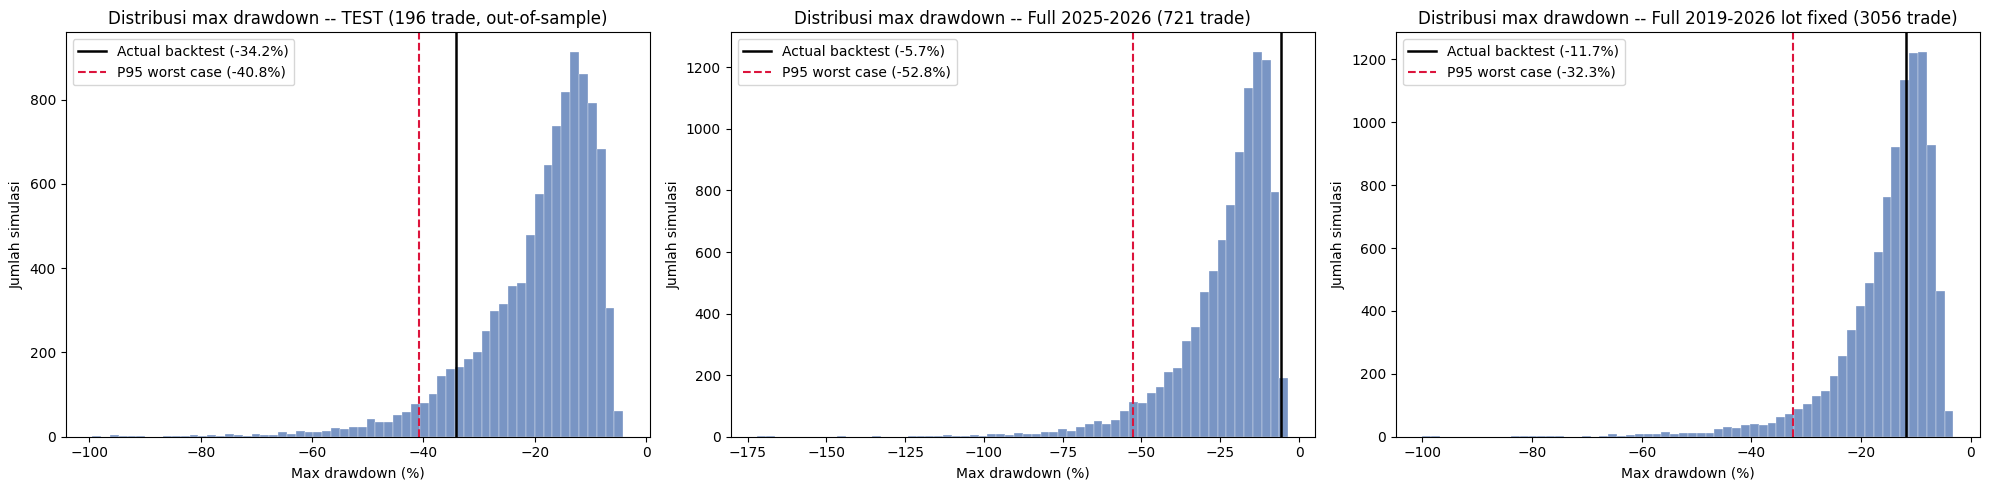

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, mc_df, actual_dd, title in [
    (axes[0], mc_test, actual_dd_test, "TEST (196 trade, out-of-sample)"),
    (axes[1], mc_full, actual_dd_full, "Full 2025-2026 (721 trade)"),
    (axes[2], mc_1926, actual_dd_1926, "Full 2019-2026 lot fixed (3056 trade)"),
]:
    ax.hist(mc_df["max_drawdown_pct"], bins=60, color="#4C72B0", alpha=0.75, edgecolor="white", linewidth=0.3)
    ax.axvline(actual_dd, color="black", linestyle="-", linewidth=1.8, label=f"Actual backtest ({actual_dd:.1f}%)")
    p95 = mc_df["max_drawdown_pct"].quantile(0.05)
    ax.axvline(p95, color="crimson", linestyle="--", linewidth=1.5, label=f"P95 worst case ({p95:.1f}%)")
    ax.set_title(f"Distribusi max drawdown -- {title}")
    ax.set_xlabel("Max drawdown (%)")
    ax.set_ylabel("Jumlah simulasi")
    ax.legend()

plt.tight_layout()
plt.savefig(EXPORT_DIR / "mc_drawdown_distribution.png", dpi=120)
plt.show()

## 7. Implikasi ke kill-switch drawdown yang sudah ada (v09)

Kill-switch live saat ini (`.env`, divalidasi di `v09_drawdown_killswitch.ipynb`):
`MAX_TOTAL_DRAWDOWN_PCT=40.0`. v09 memvalidasi angka ini dari SATU urutan trade historis v06
(1664 trade, backtest kronologis) yang tidak pernah menembus 40%. Pertanyaannya: apakah 40% itu
masih aman kalau dilihat dari distribusi Monte Carlo (bukan cuma satu urutan historis)?

In [11]:
MAX_TOTAL_DRAWDOWN_PCT = 40.0  # nilai live saat ini (.env)

for mc_df, label in [(mc_test, "TEST (196 trade)"), (mc_full, "Full 2025-2026 (721 trade)"), (mc_1926, "Full 2019-2026 lot fixed (3056 trade)")]:
    pct_breach = (mc_df["max_drawdown_pct"] <= -MAX_TOTAL_DRAWDOWN_PCT).mean() * 100
    print(f"{label}: {pct_breach:.2f}% dari {N_SIMULATIONS:,} skenario reshuffle "
          f"MENEMBUS kill-switch total {MAX_TOTAL_DRAWDOWN_PCT}% "
          f"(dgn kumpulan trade & win rate yg SAMA PERSIS dgn backtest, cuma urutan beda)")

TEST (196 trade): 5.39% dari 10,000 skenario reshuffle MENEMBUS kill-switch total 40.0% (dgn kumpulan trade & win rate yg SAMA PERSIS dgn backtest, cuma urutan beda)
Full 2025-2026 (721 trade): 11.89% dari 10,000 skenario reshuffle MENEMBUS kill-switch total 40.0% (dgn kumpulan trade & win rate yg SAMA PERSIS dgn backtest, cuma urutan beda)
Full 2019-2026 lot fixed (3056 trade): 2.59% dari 10,000 skenario reshuffle MENEMBUS kill-switch total 40.0% (dgn kumpulan trade & win rate yg SAMA PERSIS dgn backtest, cuma urutan beda)


## 8. Ringkasan sementara — kill-switch TOTAL (40%)

(Kesimpulan gabungan lengkap termasuk daily & monthly ada di Section 11 di bawah)

**Angka kunci (10.000 reshuffle tiap dataset, basis modal $100 — modal riil yang dipakai):**

| Dataset | n trade | Actual DD | Median MC | P75 | P90 | **P95** | P99 | Worst | % breach 40% |
|---|---|---|---|---|---|---|---|---|---|
| TEST out-of-sample (Mar-Agu 2026) | 196 | -34.18% | -16.47% | -24.28% | -34.21% | **-40.81%** | -58.56% | -99.5% | 5.39% |
| Full 2025-2026 (termasuk TRAIN) | 721 | -5.69% | -18.58% | -28.98% | -42.62% | **-52.84%** | -79.5% | -172%\* | 11.89% |
| **Full 2019-2026, lot FIXED** | **3056** | **-11.72%** | **-12.75%** | **-18.18%** | **-25.5%** | **-32.31%** | **-50.91%** | -100%\* | **2.59%** |

\*worst case >-100% itu artefak equity sederhana (`equity += pnl`, bukan berbasis lot dinamis) —
di dunia nyata gak bisa negatif krn broker stop-out duluan, tapi tetap sinyal risiko ekor.

Dataset sample terbesar (3056 trade, 7.6 tahun) memberi gambaran paling stabil & paling ringan
(P95=-32.31%, breach 2.59%). Sample TEST (kondisi terkini, 196 trade) P95-nya (-40.81%) sedikit
melewati kill-switch 40% (breach 5.39%) — bukan kontradiksi, sample kecil punya varians lebih
tinggi. Kill-switch total 40% cukup wajar dilihat dari data terbanyak, kurang aman kalau cuma
lihat kondisi terkini.

## 9. Perluasan: Monte Carlo untuk kill-switch DAILY & MONTHLY

Section 1-8 di atas cuma menguji `MAX_TOTAL_DRAWDOWN_PCT` (40%) -- reshuffle SEMUA trade individual
lalu hitung max drawdown dari peak equity sepanjang seluruh periode, konsisten dgn cara kill-switch
total dihitung (baseline = peak equity tertinggi yg pernah tercatat, tidak pernah reset).

`MAX_DAILY_DRAWDOWN_PCT` (20%) dan `MAX_MONTHLY_DRAWDOWN_PCT` (25%) di `.env` **belum pernah diuji
Monte Carlo** -- baseline-nya beda mekanisme (reset tiap hari/bulan kalender baru, lihat
`_check_drawdown_guard` di `m5_scalping/usecase.py`), jadi metodologinya juga harus beda.

**Percobaan pertama pakai dataset 2019-2026 GAGAL dipakai -- ditemukan masalah skala:** PnL per
trade (lot fixed 0.01) melebar drastis seiring harga emas naik -- std PnL $1.74 (2019, harga
~$1300) vs $14.37 (2026, harga ~$4300+), 8x lipat. Trade loss terbesar di seluruh dataset adalah
**-$56.66 (2026-01-30)**, lebih dari setengah basis modal $100 dalam SATU trade. Kalau dataset
2019-2026 dipakai buat estimasi daily/monthly (yg ukuran kelompoknya cuma 2-33 trade), hasil
Monte Carlo didominasi trade-trade ekstrem dari 2026 & jadi tidak realistis (breach rate 100% utk
daily) -- bukan krn strategi buruk, tapi krn PnL 2019 & 2026 digabung padahal beda skala 8x.

**Perbaikan:** dataset TEST (196 trade, Maret-Agustus 2026) dipakai sbg acuan -- SEMUA trade-nya
dari rezim harga yg SAMA (2026, konsisten dgn kondisi live SEKARANG), jadi skalanya sebanding satu
sama lain & valid dipakai buat estimasi kelompok kecil (per hari/bulan). Trade-off: sample lebih
kecil (196 vs 3056) drpd analisis total di atas, tapi ini justru BENAR utk pertanyaan "risiko
harian/bulanan di kondisi SEKARANG", bukan risiko dicampur lintas rezim harga yg berbeda 8x skala.

**Pendekatan:** hitung dulu rata-rata jumlah trade per hari & per bulan dari TEST set, lalu
reshuffle seluruh 196 PnL & kelompokkan ulang jadi "hari sintetis"/"bulan sintetis" berisi N trade
berurutan -- baseline tiap kelompok RESET ke 100 (sama seperti day_start_equity/month_start_equity
yg fixed di awal periode), ambil drawdown TERDALAM dari kelompok mana pun di tiap simulasi (krn
kill-switch breach ditentukan oleh 1 hari/bulan terburuk, bukan rata-rata).

In [12]:
# Hitung rata-rata trade/hari & trade/bulan dari TEST set (196 trade, 2026 -- rezim harga
# konsisten dgn kondisi SEKARANG, beda dgn dataset 2019-2026 yg skalanya timpang 8x, lihat
# penjelasan di atas).
df_test_dates = df_test.copy()
df_test_dates["trade_date"] = df_test_dates["entry_time"].dt.date
df_test_dates["trade_month"] = df_test_dates["entry_time"].dt.tz_localize(None).dt.to_period("M")

trades_per_day_test = df_test_dates.groupby("trade_date").size()
trades_per_month_test = df_test_dates.groupby("trade_month").size()

# Median dipakai (bukan mean) supaya gak ke-tarik hari/bulan yg kebetulan sangat ramai/sepi trade.
N_TRADES_PER_DAY = int(trades_per_day_test.median())
N_TRADES_PER_MONTH = max(1, int(trades_per_month_test.median()))
print(f"Median trade per hari (hari yg ada trade, TEST set): {N_TRADES_PER_DAY}")
print(f"Median trade per bulan (TEST set): {N_TRADES_PER_MONTH}")
print(f"PnL TEST set: min=${pnl_test.min():.2f}  max=${pnl_test.max():.2f}  std=${pnl_test.std():.2f}")
print("(dibanding dataset 2019-2026 yg std-nya melebar dari $1.74 ke $14.37 antar tahun -- TEST")
print("set skalanya konsisten krn semua dari rezim harga 2026 yg sama)")


def worst_period_dd_pct(pnl_array: np.ndarray, period_size: int, n_sims: int, rng: np.random.Generator) -> np.ndarray:
    """Reshuffle SELURUH pnl_array, potong jadi kelompok berukuran period_size (baseline reset
    ke 100 tiap kelompok, sama seperti day_start_equity/month_start_equity), ambil drawdown
    TERDALAM di antara semua kelompok per simulasi. Vectorized (numpy 2D array), bukan nested
    Python loop, supaya cukup cepat utk period_size kecil (daily, ribuan kelompok/simulasi)."""
    n_trades = len(pnl_array)
    n_groups = max(1, n_trades // period_size)
    usable = n_groups * period_size

    worst_per_sim = np.empty(n_sims)
    for sim in range(n_sims):
        shuffled = rng.permutation(pnl_array)[:usable].reshape(n_groups, period_size)
        cum = 100.0 + np.concatenate(
            [np.zeros((n_groups, 1)), np.cumsum(shuffled, axis=1)], axis=1
        )
        dd_per_group = (cum - 100.0) / 100.0 * 100  # (n_groups, period_size+1)
        worst_per_sim[sim] = dd_per_group.min()

    return worst_per_sim


worst_dd_daily = worst_period_dd_pct(pnl_test, N_TRADES_PER_DAY, N_SIMULATIONS, rng)
worst_dd_monthly = worst_period_dd_pct(pnl_test, N_TRADES_PER_MONTH, N_SIMULATIONS, rng)

print(f"\n=== Worst-case per SIMULASI (10.000x), drawdown 1 hari/bulan TERBURUK dari kelompok sintetis ===")
print(f"Daily  (n={N_TRADES_PER_DAY} trade/kelompok): median={np.median(worst_dd_daily):.2f}%  "
      f"P95={np.percentile(worst_dd_daily, 5):.2f}%  P99={np.percentile(worst_dd_daily, 1):.2f}%  "
      f"worst={worst_dd_daily.min():.2f}%")
print(f"Monthly (n={N_TRADES_PER_MONTH} trade/kelompok): median={np.median(worst_dd_monthly):.2f}%  "
      f"P95={np.percentile(worst_dd_monthly, 5):.2f}%  P99={np.percentile(worst_dd_monthly, 1):.2f}%  "
      f"worst={worst_dd_monthly.min():.2f}%")

Median trade per hari (hari yg ada trade, TEST set): 2
Median trade per bulan (TEST set): 37
PnL TEST set: min=$-37.44  max=$77.52  std=$13.87
(dibanding dataset 2019-2026 yg std-nya melebar dari $1.74 ke $14.37 antar tahun -- TEST
set skalanya konsisten krn semua dari rezim harga 2026 yg sama)



=== Worst-case per SIMULASI (10.000x), drawdown 1 hari/bulan TERBURUK dari kelompok sintetis ===
Daily  (n=2 trade/kelompok): median=-37.44%  P95=-52.35%  P99=-64.02%  worst=-72.70%
Monthly (n=37 trade/kelompok): median=-19.73%  P95=-53.90%  P99=-73.28%  worst=-135.26%


## 10. Breach rate kill-switch daily (20%) & monthly (25%) yang berlaku saat ini

In [13]:
MAX_DAILY_DRAWDOWN_PCT = 20.0  # nilai live saat ini (.env)
MAX_MONTHLY_DRAWDOWN_PCT = 25.0  # nilai live saat ini (.env)

pct_breach_daily = (worst_dd_daily <= -MAX_DAILY_DRAWDOWN_PCT).mean() * 100
pct_breach_monthly = (worst_dd_monthly <= -MAX_MONTHLY_DRAWDOWN_PCT).mean() * 100

print(f"Daily: {pct_breach_daily:.2f}% dari {N_SIMULATIONS:,} simulasi punya MINIMAL 1 hari sintetis "
      f"yang menembus kill-switch {MAX_DAILY_DRAWDOWN_PCT}%")
print(f"Monthly: {pct_breach_monthly:.2f}% dari {N_SIMULATIONS:,} simulasi punya MINIMAL 1 bulan sintetis "
      f"yang menembus kill-switch {MAX_MONTHLY_DRAWDOWN_PCT}%")
print()
print("Catatan interpretasi: breach daily/monthly TIDAK permanen (auto-reset di hari/bulan")
print("berikutnya, beda dgn total yg permanen) -- breach rate tinggi di sini WAJAR & DIHARAPKAN")
print("terjadi sesekali (itu tujuannya kill-switch harian/bulanan: membatasi kerugian dalam 1")
print("periode, bukan indikator strategi rusak spt breach total).")
print()
print("TEMUAN PENTING (daily 100% breach): dgn cuma ~2 trade/hari & trade loss terbesar di TEST")
print("set mencapai -$37 (37% dari modal $100 DALAM SATU TRADE), kill-switch 20% HAMPIR PASTI")
print("breach kalau trade sebesar itu jatuh sendirian/berpasangan dalam 1 hari -- bukan soal urutan")
print("banyak trade kecil, tapi soal 1 TRADE TUNGGAL yang lebih besar dari threshold-nya sendiri.")
print("Ini bukan bug simulasi -- ini gambaran nyata risiko konsentrasi per-trade vs modal kecil.")

Daily: 100.00% dari 10,000 simulasi punya MINIMAL 1 hari sintetis yang menembus kill-switch 20.0%
Monthly: 38.63% dari 10,000 simulasi punya MINIMAL 1 bulan sintetis yang menembus kill-switch 25.0%

Catatan interpretasi: breach daily/monthly TIDAK permanen (auto-reset di hari/bulan
berikutnya, beda dgn total yg permanen) -- breach rate tinggi di sini WAJAR & DIHARAPKAN
terjadi sesekali (itu tujuannya kill-switch harian/bulanan: membatasi kerugian dalam 1
periode, bukan indikator strategi rusak spt breach total).

TEMUAN PENTING (daily 100% breach): dgn cuma ~2 trade/hari & trade loss terbesar di TEST
set mencapai -$37 (37% dari modal $100 DALAM SATU TRADE), kill-switch 20% HAMPIR PASTI
breach kalau trade sebesar itu jatuh sendirian/berpasangan dalam 1 hari -- bukan soal urutan
banyak trade kecil, tapi soal 1 TRADE TUNGGAL yang lebih besar dari threshold-nya sendiri.
Ini bukan bug simulasi -- ini gambaran nyata risiko konsentrasi per-trade vs modal kecil.


## 11. Kesimpulan final — ketiga kill-switch (total, daily, monthly)

**Semua angka basis modal $100 (modal riil yang dipakai).** Total pakai dataset 2019-2026 (sample
terbesar, valid krn diagregasi dari peak keseluruhan). Daily/monthly pakai dataset TEST (196 trade,
2026 saja) krn dataset 2019-2026 skalanya timpang 8x antar tahun (lihat Section 9) -- utk kelompok
kecil (2-37 trade), skala yang konsisten lebih penting drpd jumlah sample.

| Kill-switch | Nilai `.env` saat ini | Breach rate (Monte Carlo) | Catatan |
|---|---|---|---|
| **Total** | 40% | 2.59% (dataset 2019-2026) — 5.39% (dataset TEST) | PERMANEN kalau breach |
| **Daily** | 20% | **100.00%** (dataset TEST) | Auto-reset besok, TAPI lihat temuan di bawah |
| **Monthly** | 25% | 38.63% (dataset TEST) | Auto-reset bulan depan |

### Temuan penting yang mengubah kesimpulan awal: kill-switch DAILY 20% nyaris SELALU breach

Ini BUKAN soal urutan banyak trade kecil yang mengumpul (spt kill-switch total) -- ini soal
**SATU TRADE TUNGGAL** yang ukurannya sendiri sudah mendekati/melebihi threshold 20%. Trade
terburuk di TEST set: **SELL 2026-03-24, SL normal kena (`exit_reason=SL`, bukan anomali), ATR
saat itu $18.72, SL=2×ATR=$37.44 poin, lot 0.01 → pnl=-$37.44 (37.4% dari modal $100 DALAM SATU
TRADE)**. Dengan cuma ~2 trade/hari, begitu 1 trade sebesar ini terjadi, kill-switch daily 20%
otomatis breach hari itu -- gak peduli urutan atau trade lain di hari yang sama.

**Kesimpulan: kill-switch daily 20% pada modal $100 dengan lot 0.01 fixed TIDAK proporsional**
terhadap risiko per-trade individual di rezim harga emas saat ini (~$4300+). Threshold 20%
efektifnya jadi "kill-switch per-trade", bukan "kill-switch akumulasi kerugian harian" seperti
tujuan aslinya -- karena 1 trade buruk saja sudah cukup men-trigger, tanpa perlu akumulasi.

**Ini beda karakter dari breach monthly (38.63%)**, yang breach-nya lebih didorong akumulasi
beberapa trade jelek dalam 1 bulan (37 trade/kelompok, lebih banyak ruang utk rugi terakumulasi
tapi juga lebih banyak ruang utk profit menutupnya) -- monthly masih berfungsi sesuai tujuannya.

### Rekomendasi (bukan keputusan otomatis — untuk didiskusikan dgn user)

- **Kill-switch daily 20% kemungkinan perlu dinaikkan** (mis. ke 35-40%, supaya 1 trade buruk
  tunggal tidak otomatis men-trigger pause harian) ATAU **modal ditingkatkan** (kill-switch % yang
  sama jadi lebih longgar dalam dolar begitu modal lebih besar dari $100) — trade-off ini
  tergantung apakah user MAU robot pause sehari penuh tiap kali ada 1 trade SL besar (proteksi
  ekstra konservatif) atau TIDAK (biarkan strategi jalan, andalkan kill-switch total/monthly saja
  utk proteksi jangka lebih panjang).
- **Kill-switch monthly 25%** masih proporsional (38.63% breach itu wajar utk kill-switch yang
  memang didesain sesekali aktif membatasi bulan buruk, bukan indikator masalah).
- **Kill-switch total 40%** masih dalam rentang wajar (lihat Section 8).
- **Tidak ada perubahan otomatis ke `.env`** — v14 murni analisis risiko, keputusan mengubah nilai
  kill-switch mana pun tetap di tangan user.

In [14]:
summary_table.to_csv(EXPORT_DIR / "monte_carlo_summary.csv")
mc_test.to_csv(EXPORT_DIR / "mc_simulations_test.csv", index=False)
mc_full.to_csv(EXPORT_DIR / "mc_simulations_full.csv", index=False)
mc_1926.to_csv(EXPORT_DIR / "mc_simulations_full_2019_2026.csv", index=False)

with open(EXPORT_DIR / "metrics.txt", "w") as f:
    f.write(f"Monte Carlo Simulation v14 -- sequence risk analysis (n_simulations={N_SIMULATIONS:,}, seed={RNG_SEED})\n\n")
    f.write("Metodologi: reshuffle urutan PnL trade v13 (TANPA penggantian), hitung ulang max_drawdown_pct\n")
    f.write("tiap kali diacak. Mengukur risiko URUTAN kejadian, bukan risiko kualitas sinyal berubah.\n\n")
    for summary in [summary_test, summary_full, summary_1926]:
        f.write(f"=== {summary['label']} ===\n")
        for k, v in summary.items():
            if k != "label":
                f.write(f"  {k}: {v}\n")
        f.write("\n")
    f.write(f"Kill-switch total saat ini (.env): {MAX_TOTAL_DRAWDOWN_PCT}%\n")
    for mc_df, label in [(mc_test, "TEST"), (mc_full, "Full 2025-2026"), (mc_1926, "Full 2019-2026 lot fixed")]:
        pct_breach = (mc_df["max_drawdown_pct"] <= -MAX_TOTAL_DRAWDOWN_PCT).mean() * 100
        f.write(f"  {label}: {pct_breach:.2f}% skenario menembus kill-switch total\n")

print("Tersimpan ke:", EXPORT_DIR)
for f in sorted(EXPORT_DIR.glob("*")):
    print(" -", f.name)

Tersimpan ke: D:\Projects\robot-scalping\dataset\exports\m5_scalping\v14
 - mc_drawdown_distribution.png
 - mc_simulations_full.csv
 - mc_simulations_full_2019_2026.csv
 - mc_simulations_test.csv
 - metrics.txt
 - monte_carlo_summary.csv
